In [ ]:
'''
Recordatorio: Quiero resolver, dado un f, la ecuación

-∆u + u = f

que tiene como forma débil

(∇u, ∇v) + (u, v) = (f, v)

para todo v

En particular, quiero saber como resolverlo cuando solo tengo f visto desde los nodos
'''

In [1]:
from mpi4py import MPI
from petsc4py import PETSc

import time
import shutil
import subprocess
from pathlib import Path

import imageio.v2 as imageio
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
import ufl

from basix.ufl import element, mixed_element
from dolfinx import fem, mesh, plot
from dolfinx.fem import petsc as fem_petsc
from scipy import sparse

try:
    import dolfinx_mpc
except ImportError:
    dolfinx_mpc = None

comm = MPI.COMM_WORLD
rank = comm.rank

In [7]:
import numpy as np
from mpi4py import MPI
import ufl
from dolfinx import fem, mesh, io
from dolfinx.fem.petsc import LinearProblem
from ufl import dx, grad, dot

# ==========================================
# 1. Mesh and Function Spaces
# ==========================================
domain = mesh.create_unit_square(MPI.COMM_WORLD, 64, 64)

# Defining standard continuous Lagrange spaces
V_main = fem.functionspace(domain, ("Lagrange", 1)) # For main variable u
V_aux  = fem.functionspace(domain, ("Lagrange", 1)) # For secondary variable phi

# Functions to store solutions
u_h = fem.Function(V_main)    # Current main solution u^n
u_n = fem.Function(V_main)    # Previous main solution u^{n-1}
phi_h = fem.Function(V_aux)   # Secondary PDE solution phi^n

# ==========================================
# 2. Parameters & Constants
# ==========================================
dt = fem.Constant(domain, 0.01)       # Time step (tau_n)
k = fem.Constant(domain, 0.1)        # Diffusion coefficient k
lmbda = fem.Constant(domain, 1.0)    # Lambda parameter

# ==========================================
# 3. Secondary PDE Formulation
#    ((∇phi, ∇psi) + (phi, psi) = (f(u_n), psi))
# ==========================================
phi = ufl.TrialFunction(V_aux)
psi = ufl.TestFunction(V_aux)

# Define your source function f(u_n). For this example, we assume f(u_n) = u_n
f_u = u_n 

a_aux = dot(grad(phi), grad(psi)) * dx + phi * psi * dx
L_aux = f_u * psi * dx

# Create the linear solver context for the secondary PDE
prob_secondary = LinearProblem(a_aux, L_aux, u=phi_h, petsc_options={"ksp_type": "preonly", "pc_type": "lu"},  petsc_options_prefix="basic_linear_problem")

# ==========================================
# 4. Main PDE Formulation (Equation 2.2)
# ==========================================
u = ufl.TrialFunction(V_main)
chi = ufl.TestFunction(V_main)

# Backward Euler time derivative approximation: (u - u_n) / dt
# We split the terms into Bilinear (left-hand side) and Linear (right-hand side) Forms

# Example placeholder for b_h(phi, u, chi). 
# Change this exact definition to match your paper's specific b_h operator!
# Let's assume it represents an advection term: b_h = (grad(phi) . grad(u)) * chi
b_h = dot(grad(phi_h), grad(u)) * chi * dx

a_main = (1.0 / dt) * u * chi * dx + k * dot(grad(u), grad(chi)) * dx + lmbda * b_h
L_main = (1.0 / dt) * u_n * chi * dx

# Create the linear solver context for the main PDE
prob_main = LinearProblem(a_main, L_main, u=u_h, petsc_options={"ksp_type": "preonly", "pc_type": "lu"},  petsc_options_prefix="basic_linear_problem")

# ==========================================
# 5. Initial Condition & Output Setup
# ==========================================
# Initialize u_n with a smooth Gaussian peak
u_n.interpolate(lambda x: 1.0 + np.exp(-((x[0]-0.5)**2 + (x[1]-0.5)**2) / 0.04))
u_h.x.array[:] = u_n.x.array[:]

# Setup ParaView storage files
vtx_u = io.VTXWriter(domain.comm, "main_sol_u.bp", [u_h])
vtx_phi = io.VTXWriter(domain.comm, "secondary_sol_phi.bp", [phi_h])

vtx_u.write(0.0)
vtx_phi.write(0.0)

# ==========================================
# 6. Time-Stepping Execution Loop
# ==========================================
t = 0.0
T_final = 1.0
step = 0

print("Beginning sequential PDE execution loop...")
while t < T_final:
    t += float(dt)
    step += 1
    
    # STEP 1: Solve the secondary PDE using u_n (updates phi_h automatically)
    prob_secondary.solve()
    
    # STEP 2: Solve the main PDE using the updated phi_h and u_n (updates u_h automatically)
    prob_main.solve()
    
    # Save fields to file
    vtx_u.write(t)
    vtx_phi.write(t)
    
    # STEP 3: Progress time by assigning current solution to the old solution placeholder
    u_n.x.array[:] = u_h.x.array[:]
    
    if step % 10 == 0:
        print(f"Step {step} completed | Time = {t:.2f}")

vtx_u.close()
vtx_phi.close()
print("Simulation complete.")

ld: warning: duplicate -rpath '/Users/diego/miniconda3/envs/dolfinx/lib' ignored
ld: warning: duplicate -rpath '/Users/diego/miniconda3/envs/dolfinx/lib' ignored


Beginning sequential PDE execution loop...
Step 10 completed | Time = 0.10
Step 20 completed | Time = 0.20
Step 30 completed | Time = 0.30
Step 40 completed | Time = 0.40
Step 50 completed | Time = 0.50
Step 60 completed | Time = 0.60
Step 70 completed | Time = 0.70
Step 80 completed | Time = 0.80
Step 90 completed | Time = 0.90
Step 100 completed | Time = 1.00
Simulation complete.


/var/folders/8x/2_xy04_n0gs51pp95f6ltysh0000gn/T/ipykernel_66129/4255495754.py:23: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  plotter.show()


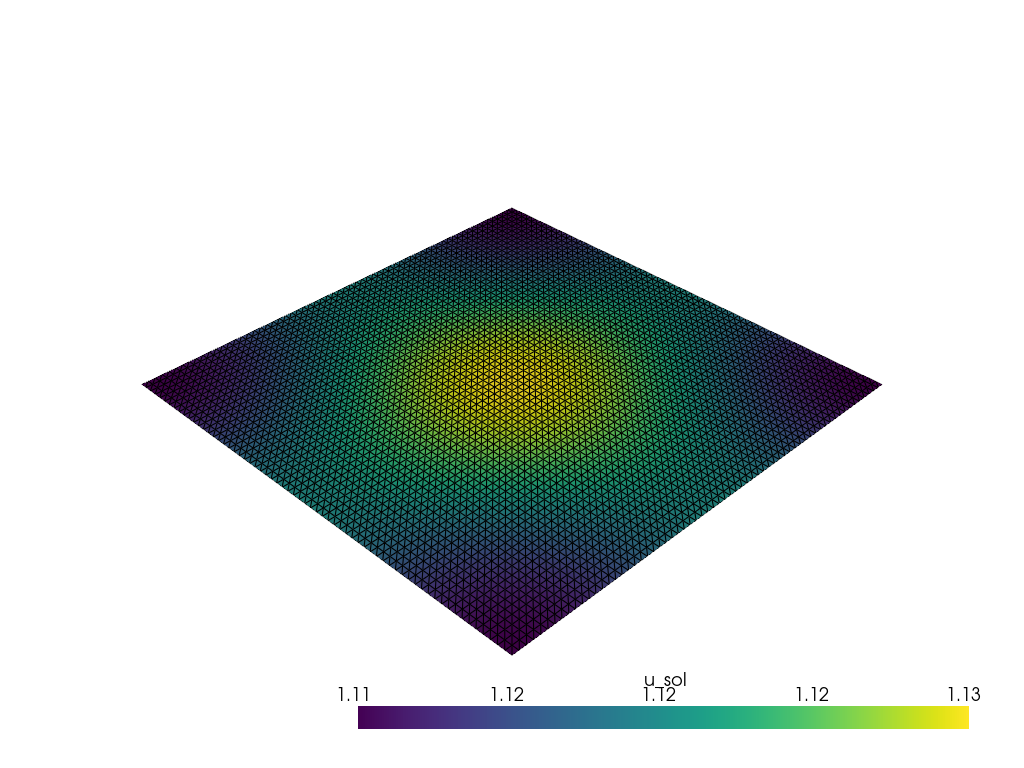

In [9]:
import pyvista as pv
from dolfinx import plot

# 1. Start a PyVista plotting window
plotter = pv.Plotter(title="Keller-Segel Solution Visualization")

# 2. Extract the mesh topology and geometry from your FEniCS FunctionSpace
topology, cell_types, geometry = plot.vtk_mesh(V_main)

# 3. Create a PyVista unstructured grid
grid = pv.UnstructuredGrid(topology, cell_types, geometry)

# 4. Attach your current solution array (u_h) to the grid points
grid.point_data["u_sol"] = u_h.x.array.real

# 5. Optional: Warp the mesh by your solution values to create 3D peaks
warped_grid = grid.warp_by_scalar(scalars="u_sol", factor=0.1)

# 6. Add the warped mesh to your plotter window
plotter.add_mesh(warped_grid, cmap="viridis", show_edges=True)

# 7. Open the interactive window
plotter.show()

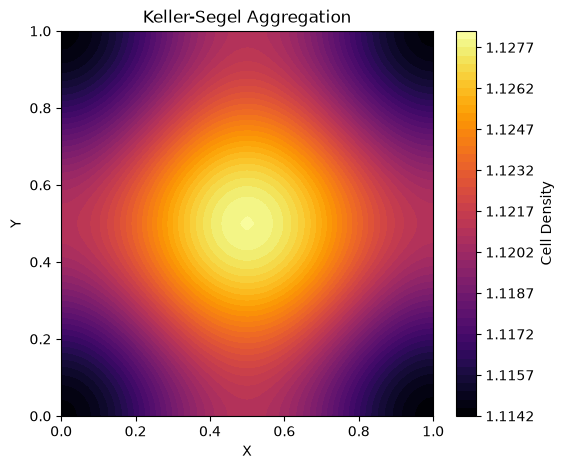

In [10]:
import matplotlib.pyplot as plt

# Extract coordinates and solution values
points = V_main.tabulate_dof_coordinates()[:, :2] # Get X and Y coordinates
x, y = points[:, 0], points[:, 1]
values = u_h.x.array.real

# Use matplotlib's triangulation mapping to handle finite element nodes
plt.figure(figsize=(6, 5))
plt.tricontourf(x, y, values, levels=50, cmap='inferno')
plt.colorbar(label='Cell Density')
plt.title('Keller-Segel Aggregation')
plt.xlabel('X')
plt.ylabel('Y')
plt.savefig('keller_segel_snapshot.png', dpi=300)
plt.show()

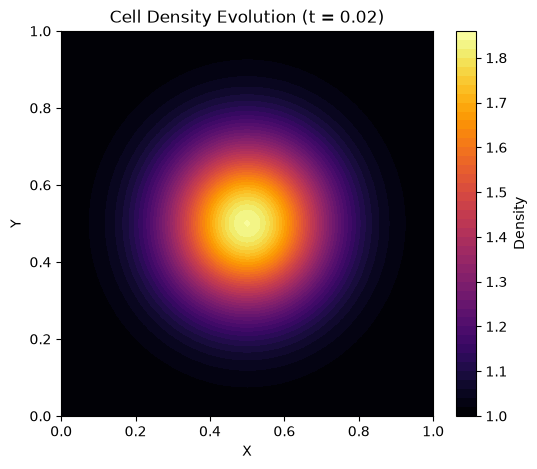

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [11]:
import matplotlib.pyplot as plt

# ==========================================
# Setup Matplotlib Plotting Window
# ==========================================
# Turn on interactive mode for live updating
plt.ion() 
fig, ax = plt.subplots(figsize=(6, 5))

# Extract the grid coordinates once before the loop
points = V_main.tabulate_dof_coordinates()[:, :2]
x, y = points[:, 0], points[:, 1]

# Set up initial condition
u_n.interpolate(lambda x: 1.0 + np.exp(-((x[0]-0.5)**2 + (x[1]-0.5)**2) / 0.04))
u_h.x.array[:] = u_n.x.array[:]

# ==========================================
# Execution Loop with Live Plotting
# ==========================================
t = 0.0
T_final = 1.0
step = 0

while t < T_final:
    t += float(dt)
    step += 1
    
    # Solve the PDEs for this step
    prob_secondary.solve()
    prob_main.solve()
    
    # --- Live Plotting Update ---
    if step % 2 == 0:  # Update plot every 2 steps to preserve CPU speed
        ax.clear()     # Clear previous frame's contours
        
        # Draw the updated contour mapping
        values = u_h.x.array.real
        contour = ax.tricontourf(x, y, values, levels=50, cmap='inferno')
        
        # Keep formatting consistent
        ax.set_title(f"Cell Density Evolution (t = {t:.2f})")
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        
        # Add a colorbar only on the very first render, or clear/recreate it
        if step == 2:
            cbar = fig.colorbar(contour, ax=ax, label='Density')
        
        plt.draw()
        plt.pause(0.001)  # Briefly pause to let GUI update the image
    # ----------------------------
    
    # Progress time state
    u_n.x.array[:] = u_h.x.array[:]

plt.ioff() # Turn off interactive mode when done
plt.show() # Keep final frame open

In [12]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# 1. Initialize Figure
fig, ax = plt.subplots(figsize=(6, 5))
points = V_main.tabulate_dof_coordinates()[:, :2]
x, y = points[:, 0], points[:, 1]

# Re-initialize state
u_n.interpolate(lambda x: 1.0 + np.exp(-((x[0]-0.5)**2 + (x[1]-0.5)**2) / 0.04))
u_h.x.array[:] = u_n.x.array[:]

frames_data = [] # To store snapshots of solution arrays
time_values = [] # To store timestamps

t = 0.0
T_final = 1.0

print("Running simulation and capturing frames...")
while t < T_final:
    t += float(dt)
    prob_secondary.solve()
    prob_main.solve()
    
    # Save a deep copy of the numerical values array for this time step
    frames_data.append(np.array(u_h.x.array.real))
    time_values.append(t)
    
    u_n.x.array[:] = u_h.x.array[:]

# 2. Define the Animation Update Function
def update(frame_idx):
    ax.clear()
    current_values = frames_data[frame_idx]
    current_time = time_values[frame_idx]
    
    # Render frame
    contour = ax.tricontourf(x, y, current_values, levels=50, cmap='inferno')
    ax.set_title(f"Cell Density Evolution (t = {current_time:.2f})")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    return contour

# 3. Build and Save the Animation
print("Compiling animation file...")
anim = FuncAnimation(fig, update, frames=len(frames_data), interval=50)

# Save as GIF (Requires 'pillow' package installed via pip)
writer = PillowWriter(fps=20)
anim.save("keller_segel_evolution.gif", writer=writer)
print("Saved as keller_segel_evolution.gif")

Running simulation and capturing frames...
Compiling animation file...
Saved as keller_segel_evolution.gif
